# Capitales Del Mundo: Del HTML Al DataFrame

![Mapa del mundo](https://upload.wikimedia.org/wikipedia/commons/8/80/World_map_-_low_resolution.svg)

En este cuaderno, el dataset protagonista es una tabla de capitales en Wikipedia.
Vas a convertir una pagina web en datos limpios listos para analizar.

# Ejercicio 1 (Guiado): Web Scraping Basico

Objetivo: extraer una tabla de Wikipedia, limpiarla y generar un primer mini-analisis visual.

Ruta de trabajo:
1. Descargar HTML
2. Parsear con BeautifulSoup
3. Encontrar tabla
4. Extraer filas
5. Crear DataFrame
6. Visualizar y guardar

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## Paso 1: Descargar la pagina

In [4]:
url = 'https://es.wikipedia.org/wiki/Anexo:Capitales_de_Estado'
headers = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/124.0.0.0 Safari/537.36'
    )
}

response = requests.get(url, headers=headers, timeout=30)
response.raise_for_status()

print('Estado HTTP:', response.status_code)
print('Caracteres descargados:', len(response.text))

Estado HTTP: 200
Caracteres descargados: 610795


## Paso 2 y 3: Parsear HTML y localizar la tabla

In [5]:
soup = BeautifulSoup(response.text, 'html.parser')
tablas = soup.find_all('table', class_=['wikitable', 'sortable'])
if not tablas:
    tablas = soup.find_all('table')

print('Tablas candidatas encontradas:', len(tablas))
tabla = tablas[0]
print('Clase de la tabla seleccionada:', tabla.get('class'))

cabeceras = []
for fila in tabla.find_all('tr'):
    posibles = [c.get_text(' ', strip=True).split('[')[0].strip() for c in fila.find_all(['td', 'th'])]
    if len(posibles) == 4 and all(posibles):
        cabeceras = posibles
        break

if not cabeceras:
    cabeceras = ['Entidad', 'Capital', 'Continente', 'Habitantes']

print('Cabeceras detectadas:', cabeceras)
cabeceras

Tablas candidatas encontradas: 1
Clase de la tabla seleccionada: ['sortable']
Cabeceras detectadas: ['Entidad', 'Capital', 'Continente', 'Habitantes']


['Entidad', 'Capital', 'Continente', 'Habitantes']

## Paso 4 y 5: Extraer registros y construir DataFrame

In [6]:
filas_datos = []
for fila in tabla.find_all('tr'):
    celdas = fila.find_all(['td', 'th'])
    if len(celdas) != 4:
        continue

    fila_limpia = []
    for celda in celdas:
        texto = celda.get_text(' ', strip=True)
        texto = texto.split('[')[0].strip()
        fila_limpia.append(texto)

    if fila_limpia != cabeceras:
        filas_datos.append(fila_limpia)

df = pd.DataFrame(filas_datos, columns=cabeceras)
print('Shape:', df.shape)
df.head()

Shape: (240, 4)


,Entidad,Capital,Continente,Habitantes
0,Abjasia Abjasia ( estado con reconocimiento li...,Sujumi,Asia - Europa,65 530
1,Acrotiri y Dhekelia Acrotiri y Dhekelia (bases...,Episkopí,Asia - Europa,3304
2,Afganistán Afganistán,Kabul,Asia,5 032 768
3,Albania Albania,Tirana,Europa,825 687
4,Alemania Alemania,Berlín,Europa,6 312 568


## Paso 6: Visualización exploratoria rápida del dataset

Para visualizar algo sencillo, contamos iniciales del pais (primera letra de la primera columna).

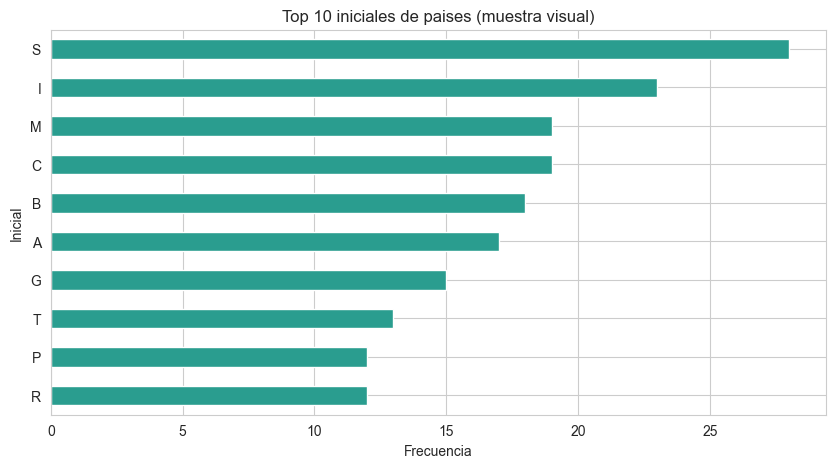

In [7]:
col_pais = df.columns[0]
iniciales = df[col_pais].astype(str).str[0].str.upper().value_counts().head(10)

ax = iniciales.sort_values().plot(kind='barh', color='#2a9d8f')
ax.set_title('Top 10 iniciales de paises (muestra visual)')
ax.set_xlabel('Frecuencia')
ax.set_ylabel('Inicial')
plt.show()

In [11]:
from pathlib import Path

csv_path = Path('capitales_paises.csv')
xlsx_path = Path('capitales_paises.xlsx')

# Guardado principal (siempre)
df.to_csv(csv_path, index=False, encoding='utf-8')
print(f'CSV generado: {csv_path.resolve()}')

# Guardado opcional a Excel (requiere openpyxl)
try:
    df.to_excel(xlsx_path, index=False)
    print(f'Excel generado: {xlsx_path.resolve()}')
except ImportError:
    print("Excel no generado: falta 'openpyxl'.")
    print("Si lo necesitas, instala con: pip install openpyxl")

CSV generado: C:\EDUCACION\DATA-ANALYST\da-satelites\da-sat-05-curie-eda\02-carga-datos\01-web-scraping\capitales_paises.csv
Excel no generado: falta 'openpyxl'.
Si lo necesitas, instala con: pip install openpyxl


## Checklist final
- [ ] He entendido el flujo descargar -> parsear -> extraer
- [ ] He generado DataFrame limpio
- [ ] He creado al menos una visualizacion
- [ ] He exportado resultados